In [ ]:
"""Hero-Chart 4 (H5): Aufmerksamkeit vs. Volumen, Quadranten-Analyse 2024.

Kernfrage: Spiegelt die parlamentarische Aufmerksamkeit auf digitale Themen
die tatsaechliche Mittelverteilung im Digitalhaushalt wider?

Inputs:
  outputs/h5_panel.csv   (Join aus Notebook 04: ZEW x CPP-BT Plenarprotokolle)

Outputs:
  figures/h5_quadranten.png  (200 DPI)
  figures/h5_quadranten.pdf
"""

'Hero-Chart 4 (H5): Aufmerksamkeit vs. Volumen — Quadranten-Analyse 2024.\n\nKernfrage: Spiegelt die parlamentarische Aufmerksamkeit auf digitale Themen\ndie tatsaechliche Mittelverteilung im Digitalhaushalt wider?\n\nInputs:\n  outputs/h5_panel.csv   (Join aus Notebook 04: ZEW x CPP-BT Plenarprotokolle)\n\nOutputs:\n  figures/h5_quadranten.png  (200 DPI)\n  figures/h5_quadranten.pdf\n'

## Kernfrage und Essay-Bezug (Akt 4)

Der Digitalhaushalt ist nicht nur in seinen Mitteln polyzentrisch (Akt 1), sondern
auch in seiner parlamentarischen Wahrnehmung. **Akt 4** verschneidet die
Haushaltsdaten (ZEW/Agora) mit dem CPP-BT-Korpus der Bundestagsreden (Fobbe 2026):
Welche Ressorts bekommen mehr Debattenraum als ihr Volumen erwarten ließe und
welche finanzieren still im Hintergrund?

Der Bubble-Chart stellt für 2024 den **parlamentarischen Aufmerksamkeits-Anteil**
(Anteil digitalbezogener Reden an allen Reden pro Jahr, in Promille) gegen den
**Volumen-Anteil** (Anteil am Digital-Soll, in Prozent) gegenüber. Die Mediane
beider Dimensionen definieren die vier Quadranten. Bubble-Größe: absolutes
Digital-Soll in Mrd. Euro. EP 60 (Allgemeine Finanzverwaltung) wird exkludiert,
da es kein parlamentarisches Ressort mit eigenen Rednern ist.

In [2]:
import sys
sys.path.insert(0, '..')  # repo root, relativ zum notebooks/-Verzeichnis

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display

from src import FIGURES_DIR, OUTPUTS_DIR
from src.style import apply_style, COLORS, add_quelle

apply_style()

In [ ]:
# Daten laden, Panel aus Notebook 04 (ZEW x CPP-BT Join)
panel = pd.read_csv(OUTPUTS_DIR / 'h5_panel.csv')

# 2024, EP60 exkludiert
p24 = panel[(panel['jahr'] == 2024) & (panel['ressort'] != 'EP60')].copy()
jahres_sum = p24['mrd_eur'].sum()
p24['vol_anteil'] = p24['mrd_eur'] / jahres_sum * 100

# Rang-Analyse (Diskrepanz-Indikator: pos. = mehr Volumen als Aufmerksamkeit)
p24['rang_vol'] = p24['mrd_eur'].rank(ascending=False)
p24['rang_aufm'] = p24['reden_anteil_promille'].rank(ascending=False)
p24['diskrepanz'] = p24['rang_aufm'] - p24['rang_vol']

med_x = p24['reden_anteil_promille'].median()
med_y = p24['vol_anteil'].median()

tbl = (
    p24[['ressort', 'mrd_eur', 'vol_anteil', 'reden_anteil_promille', 'diskrepanz']]
    .sort_values('diskrepanz')
    .rename(columns={
        'ressort': 'Ressort',
        'mrd_eur': 'Vol. (Mrd. \u20ac)',
        'vol_anteil': 'Volumen-Anteil (%)',
        'reden_anteil_promille': 'Aufmerksamkeit (\u2030)',
        'diskrepanz': 'Diskrepanz (Rang)',
    })
    .round(2)
)
display(tbl)
print(f'Median Aufmerksamkeit: {med_x:.2f} \u2030  |  Median Volumen-Anteil: {med_y:.2f} %')

,Ressort,Vol. (Mrd. €),Volumen-Anteil (%),Aufmerksamkeit (‰),Diskrepanz (Rang)
3,BMI,1.98,11.83,10.23,-4.0
23,BMG,0.27,1.64,1.97,-1.0
19,BMVg,3.12,18.61,4.32,0.0
27,BMBF,3.88,23.15,8.14,0.0
7,BMF,2.00,11.94,2.22,1.0
11,BMWK,1.38,8.24,1.60,1.0
15,BMDV,4.12,24.60,2.96,3.0


Median Aufmerksamkeit: 2.96 ‰  |  Median Volumen-Anteil: 11.94 %


## Quadranten-Methodik

Der Diskrepanz-Indikator misst die Rang-Differenz zwischen Aufmerksamkeit und Volumen:

- **Positiv (> 0):** Ressort wird höher im Volumen gerankt als in der Aufmerksamkeit
  → potenzielles *stilles Schwergewicht* (finanziert mehr als es debattiert wird)
- **Null:** Ränge stimmen überein → *Match*
- **Negativ (< 0):** Ressort wird höher in der Aufmerksamkeit als im Volumen gerankt
  → potenzielles *Buzz-Ressort* (debattiert mehr als es finanziert)

Die gestrichelten Linien markieren die Mediane beider Dimensionen. Da sieben
Ressorts analysiert werden, entsprechen die Mediane jeweils dem vierten Rang —
BMDV (Aufmerksamkeit-Rang 4) und BMF (Volumen-Rang 4) liegen damit exakt auf
den Median-Linien.

Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h5_quadranten.png
Gespeichert: /Users/moe/Documents/GitHub/agora_challenge/figures/h5_quadranten.pdf


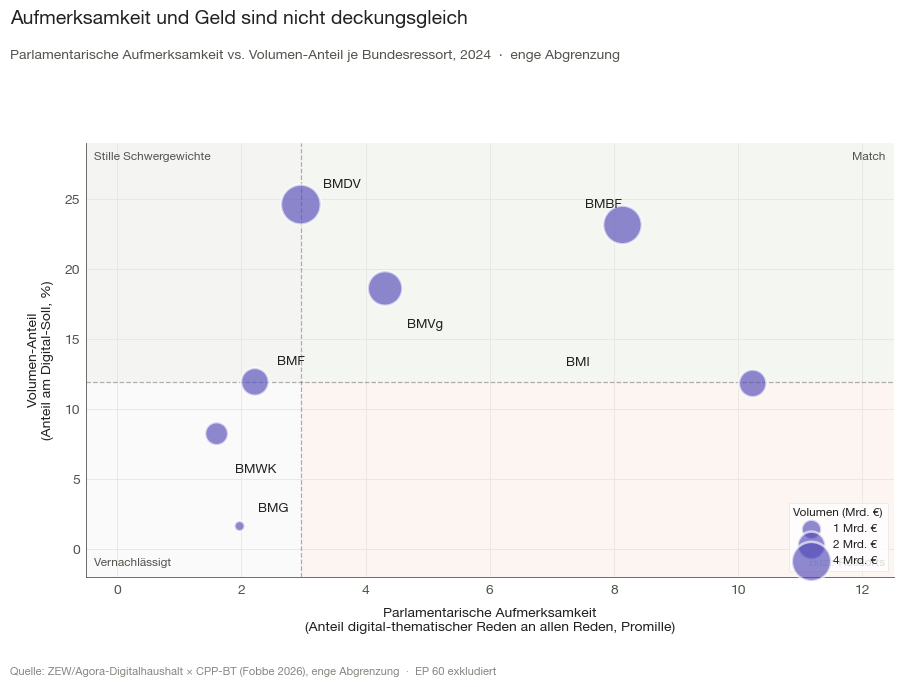

In [4]:
# Chart: Bubble-Chart Aufmerksamkeit vs. Volumen 2024
fig, ax = plt.subplots(figsize=(9.5, 7.0))
fig.subplots_adjust(left=0.10, right=0.95, top=0.78, bottom=0.16)

X_MIN, X_MAX = -0.5, 12.5
Y_MIN, Y_MAX = -2.0, 29.0
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)

# Grid auf beide Achsen
ax.grid(True, axis='both', color=COLORS['grid'], linewidth=0.6, zorder=0)
ax.set_axisbelow(True)

# Quadrant-Hintergruende (sehr dezent)
quad = [
    Rectangle((X_MIN, med_y), med_x - X_MIN, Y_MAX - med_y,
               facecolor=COLORS['neutral'], alpha=0.09, zorder=0),   # upper-left
    Rectangle((med_x, med_y), X_MAX - med_x, Y_MAX - med_y,
               facecolor=COLORS['aufstieg'], alpha=0.06, zorder=0),  # upper-right
    Rectangle((X_MIN, Y_MIN), med_x - X_MIN, med_y - Y_MIN,
               facecolor=COLORS['neutral'], alpha=0.04, zorder=0),   # lower-left
    Rectangle((med_x, Y_MIN), X_MAX - med_x, med_y - Y_MIN,
               facecolor=COLORS['highlight'], alpha=0.06, zorder=0), # lower-right
]
for r in quad:
    ax.add_patch(r)

# Median-Linien
ax.axhline(med_y, color=COLORS['text_secondary'], linewidth=0.9,
           linestyle='--', zorder=2, alpha=0.45)
ax.axvline(med_x, color=COLORS['text_secondary'], linewidth=0.9,
           linestyle='--', zorder=2, alpha=0.45)

# Bubbles (Groesse proportional zu absolutem Volumen)
SIZE_SCALE = 200
ax.scatter(
    p24['reden_anteil_promille'], p24['vol_anteil'],
    s=p24['mrd_eur'] * SIZE_SCALE,
    c=COLORS['akzent'], alpha=0.65,
    edgecolors='white', linewidth=1.8, zorder=3,
)

# Ressort-Labels (manuelle Offsets in Daten-Koordinaten)
LABEL_OFFSETS = {
    'BMDV': (0.35, 1.0),
    'BMBF': (-0.6, 1.0),
    'BMVg': (0.35, -2.2),
    'BMI':  (-3.0, 1.0),
    'BMF':  (0.35, 1.0),
    'BMWK': (0.30, -2.2),
    'BMG':  (0.30, 0.8),
}
for _, row in p24.iterrows():
    ox, oy = LABEL_OFFSETS.get(row['ressort'], (0.35, 0.9))
    ax.annotate(
        row['ressort'],
        xy=(row['reden_anteil_promille'], row['vol_anteil']),
        xytext=(row['reden_anteil_promille'] + ox, row['vol_anteil'] + oy),
        fontsize=9.5, color=COLORS['text'], weight='medium',
        va='bottom' if oy > 0 else 'top', ha='left',
        annotation_clip=False,
    )

# Quadrant-Labels (Ecken, Achsen-Koordinaten)
ql = dict(fontsize=8.5, color=COLORS['text_secondary'], style='italic', zorder=5)
ax.text(0.01, 0.98, 'Stille Schwergewichte', transform=ax.transAxes,
        va='top', ha='left', **ql)
ax.text(0.99, 0.98, 'Match', transform=ax.transAxes,
        va='top', ha='right', **ql)
ax.text(0.01, 0.02, 'Vernachl\u00e4ssigt', transform=ax.transAxes,
        va='bottom', ha='left', **ql)
ax.text(0.99, 0.02, 'Buzz-Ressorts', transform=ax.transAxes,
        va='bottom', ha='right', **ql)

# Achsenbeschriftung
ax.set_xlabel(
    'Parlamentarische Aufmerksamkeit\n'
    '(Anteil digital-thematischer Reden an allen Reden, Promille)',
    labelpad=8,
)
ax.set_ylabel('Volumen-Anteil\n(Anteil am Digital-Soll, %)', labelpad=8)

# Bubble-Gr\u00f6ssen-Legende
for vol, lbl in [(1.0, '1 Mrd. \u20ac'), (2.0, '2 Mrd. \u20ac'), (4.0, '4 Mrd. \u20ac')]:
    ax.scatter([], [], s=vol * SIZE_SCALE, c=COLORS['akzent'], alpha=0.65,
               edgecolors='white', linewidth=1.8, label=lbl)
leg = ax.legend(
    title='Volumen (Mrd. \u20ac)', loc='lower right',
    frameon=True, fancybox=False, edgecolor=COLORS['grid'],
    fontsize=8.5, title_fontsize=8.5,
)
leg.get_frame().set_linewidth(0.6)

# Titel
fig.text(
    0.02, 0.95,
    'Aufmerksamkeit und Geld sind nicht deckungsgleich',
    fontsize=14, weight='medium', color=COLORS['text'],
)
fig.text(
    0.02, 0.90,
    'Parlamentarische Aufmerksamkeit vs. Volumen-Anteil je Bundesressort, 2024  \u00b7  enge Abgrenzung',
    fontsize=10, color=COLORS['text_secondary'],
)

add_quelle(
    ax,
    'Quelle: ZEW/Agora-Digitalhaushalt \u00d7 CPP-BT (Fobbe 2026), enge Abgrenzung  \u00b7  EP 60 exkludiert',
)

# Export
FIGURES_DIR.mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / 'h5_quadranten.png', dpi=200)
fig.savefig(FIGURES_DIR / 'h5_quadranten.pdf')
print(f'Gespeichert: {FIGURES_DIR / "h5_quadranten.png"}')
print(f'Gespeichert: {FIGURES_DIR / "h5_quadranten.pdf"}')
plt.show()

## Quadranten-Befund 2024

**BMDV als strukturelles stilles Schwergewicht.** Das BMDV führt 2024 den
Digitalhaushalt mit 4,12 Mrd. € (24,5 % Volumen-Anteil, Rang 1). Seine
parlamentarische Präsenz zu digitalen Themen liegt mit 2,96 Promille jedoch
exakt auf dem Median — Aufmerksamkeits-Rang 4 von 7. Die Diskrepanz
(Rang-Differenz +3) ist die stärkste im Datensatz. Breitband- und
ETCS-Investitionen fließen, ohne im Digitalraum des Bundestages besonders
sichtbar zu sein.

**BMI als klares Buzz-Ressort.** Das BMI hält 2024 Rang 5 im Volumen
(1,98 Mrd. €, 11,8 % Anteil), aber Rang 1 in der parlamentarischen
Aufmerksamkeit (10,23 Promille). Diskrepanz −4. Cybersicherheit, BSI,
Digitalfunk und Verwaltungsdigitalisierung ziehen Debatten weit über ihren
Mittelanteil hinaus.

**BMBF und BMVg: Match.** Beide Ressorts zeigen 2024 ausgeglichene Profile
(Diskrepanz 0): ihre parlamentarische Sichtbarkeit entspricht ihrem
Volumen-Anteil.

**BMF und BMWK: milde Diskrepanz.** Beide erhalten etwas weniger
parlamentarische Aufmerksamkeit als ihr Volumen erwarten ließe
(Diskrepanz je +1).

**EP 60 (nicht im Chart).** Der Schatten-Förderkanal EP 60 ist bewusst
exkludiert: Er hat in 2024 nur 0,07 Mrd. € (nach dem Mikroelektronik-Peak
2023) und null Reden-Treffer, da die Allgemeine Finanzverwaltung kein
ressortspezifisches parlamentarisches Profil hat.

**Verbindung zu Akt 1.** Die Polyzentrik der Mittel (H1) und die
Polyzentrik der parlamentarischen Aufmerksamkeit (H5) sind nicht
deckungsgleich. Das BMDV regiert das Geld, das BMI regiert die Schlagzeilen.
Für ein BMDS, das Klassifikations- und Transparenzhoheit übernehmen will,
bedeutet das: Die Ressorts mit dem stärksten politischen Diskurs (BMI) sind
nicht dieselben wie die Ressorts mit den größten Mittelvolumina (BMDV, BMBF).